<a href="https://colab.research.google.com/github/cailuj/TCC/blob/main/fase_2_vgg16_grid_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GridSearch com VGG16

## Configuração e Carregamento de Dados do Drive

In [ ]:
import pandas as pd
import tensorflow as tf
import itertools
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.backend import clear_session
from google.colab import drive
import itertools
import json

drive.mount('/content/drive')

Mounted at /content/drive


## Pipeline dos dados e One-Hot Encoding


In [ ]:
dataset_path = Path('/content/drive/MyDrive/organized data')

filepaths = []
labels = []

if dataset_path.exists():
    for filepath in dataset_path.glob('*/*'):
        if filepath.is_file():
            filepaths.append(str(filepath))
            labels.append(filepath.parent.name)

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    print(f"Total images found: {len(df)}")

    if not df.empty:
        train_val_df, test_df = train_test_split(
            df,
            test_size=0.2,
            stratify=df['label'],
            random_state=42
        )

        train_df, val_df = train_test_split(
            train_val_df,
            test_size=0.2,
            stratify=train_val_df['label'],
            random_state=42
        )

        unique_labels = df['label'].unique()
        label_to_int = {label: i for i, label in enumerate(unique_labels)}

        train_df['label_encoded'] = train_df['label'].map(label_to_int)
        val_df['label_encoded'] = val_df['label'].map(label_to_int)
        test_df['label_encoded'] = test_df['label'].map(label_to_int)

        print(f"Training set size: {len(train_df)} ({len(train_df)/len(df):.1%})")
        print(f"Validation set size: {len(val_df)} ({len(val_df)/len(df):.1%})")
        print(f"Test set size: {len(test_df)} ({len(test_df)/len(df):.1%})")

        print(train_df.head())
        print("\nData loaded and split successfully.")
    else:
        print("No images found in the specified directory.")
else:
    print(f"Directory not found: {dataset_path}")

Total images found: 7809
Training set size: 4997 (64.0%)
Validation set size: 1250 (16.0%)
Test set size: 1562 (20.0%)
                                               filepath   label  label_encoded
2079  /content/drive/MyDrive/organized data/benign/D...  benign              0
82    /content/drive/MyDrive/organized data/benign/A...  benign              0
5708  /content/drive/MyDrive/organized data/normal/A...  normal              2
176   /content/drive/MyDrive/organized data/benign/A...  benign              0
1961  /content/drive/MyDrive/organized data/benign/A...  benign              0

Data loaded and split successfully.


One-hot encoding se fez necessário pela quantidade de classes

Os dados foram divididos em 20% para teste, do restante 20% para validação e 80% para treino.

In [ ]:
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.keras.applications.vgg16.preprocess_input(img)
    label = tf.one_hot(label, depth=3)
    return img, label

if 'train_df' in locals():
    train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label_encoded'].values))
    val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_df['label_encoded'].values))
    test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label_encoded'].values))

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.map(process_image, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.map(process_image, num_parallel_calls=AUTOTUNE)
    test_ds = test_ds.map(process_image, num_parallel_calls=AUTOTUNE)

    BATCH_SIZE = 32
    SHUFFLE_BUFFER = 1000

    train_ds = train_ds.shuffle(SHUFFLE_BUFFER).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    print(train_ds.element_spec)
else:
    print("Error: train_df is not defined. Please run the data loading cell first.")

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))


##Grid Search


In [ ]:
history_storage = {}
combinations = [
    ('swish', 0.001, 'Adam'),
    ('relu', 0.0001, 'SGD'),
    ('swish', 0.0001, 'SGD'),
]
print(f"\nTotal combinations to test: {len(combinations)}")

for i, (act, lr, opt_name) in enumerate(combinations):
    clear_session()

    model_name = f"{act}_{lr}_{opt_name}"
    print(f"\nTraining model {i+1}/{len(combinations)}: {model_name}")

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation=act)(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs, outputs)

    if opt_name == 'Adam':
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        verbose=1
    )

    history_storage[model_name] = history.history
    final_val_recall = history.history['val_recall'][-1]
    print(f"Finished {model_name} - Final Val Recall: {final_val_recall:.4f}")


Total combinations to test: 3

Training model 1/3: swish_0.001_Adam
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 217s 904ms/step - accuracy: 0.5854 - loss: 0.9348 - precision: 0.6162 - recall: 0.5337 - val_accuracy: 0.6240 - val_loss: 0.7797 - val_precision: 0.6763 - val_recall: 0.5432
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.6746 - loss: 0.6736 - precision: 0.7144 - recall: 0.6192 - val_accuracy: 0.6568 - val_loss: 0.7302 - val_precision: 0.7064 - val_recall: 0.6024
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7310 - loss: 0.5949 - precision: 0.7614 - recall: 0.6840 - val_accuracy: 0.6320 - val_loss: 0.8019 - val_precision: 0.6728 - val_recall: 0.5824
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7721 - loss: 0.5196 - precision: 0.8021 - recall: 0.7364 - val_accuracy: 0.6536 - val_loss: 0.7855 - val_precision: 0.6774 - val_recall: 0.6200
Epoch 5/100
157/157 ━━━

## Visualizando as performances


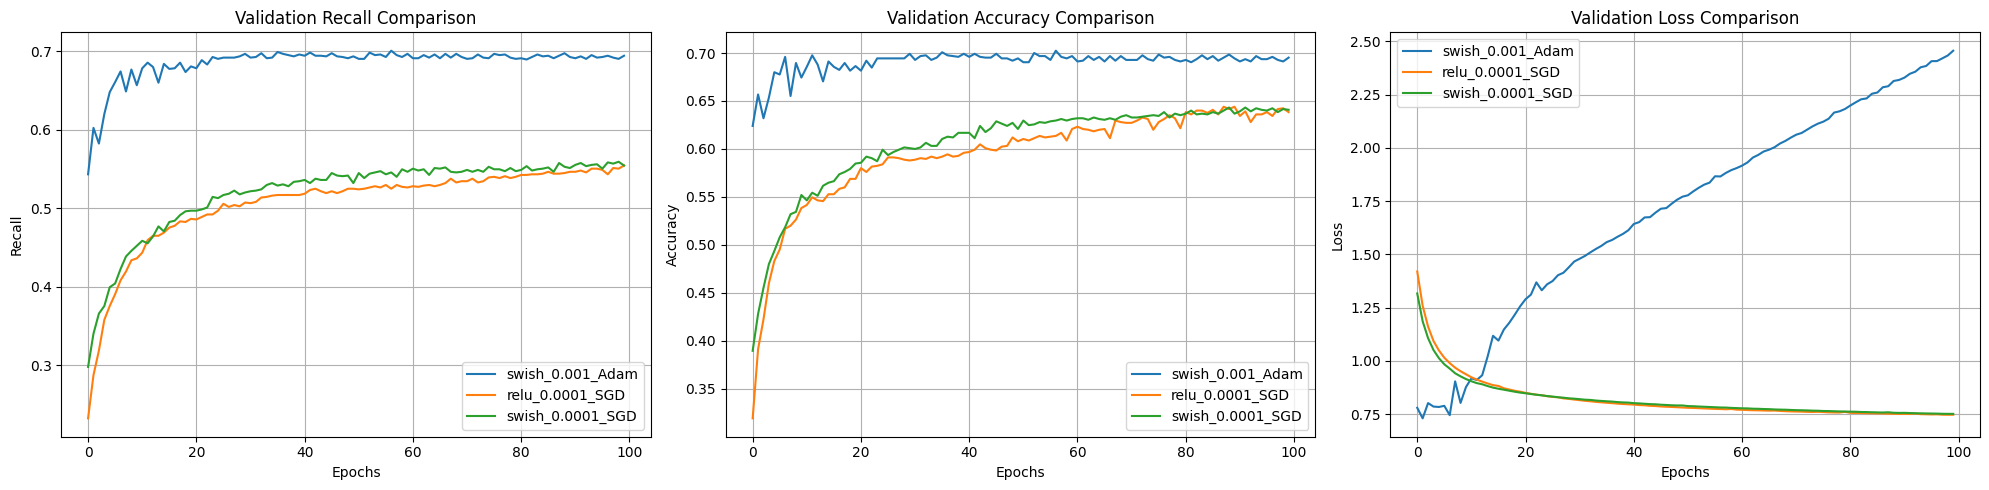

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for model_name, history in history_storage.items():
    val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)
    if val_recall_key:
        axes[0].plot(history[val_recall_key], label=model_name)

    if 'val_accuracy' in history:
        axes[1].plot(history['val_accuracy'], label=model_name)

    if 'val_loss' in history:
        axes[2].plot(history['val_loss'], label=model_name)

axes[0].set_title('Validation Recall Comparison')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Recall')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].set_title('Validation Loss Comparison')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Selecionando melhor modelo

In [ ]:
best_model_name = ""
best_val_recall = -1.0

if 'history_storage' in locals() and history_storage:
    for model_name, history in history_storage.items():
        val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)

        if val_recall_key:
            max_val_recall = max(history[val_recall_key])
            if max_val_recall > best_val_recall:
                best_val_recall = max_val_recall
                best_model_name = model_name
else:
    print("History storage is empty. Check Grid Search execution.")

if best_model_name:
    print(f"Best Model Selected: {best_model_name} with Val Recall: {best_val_recall:.4f}")

    best_act, best_lr_str, best_opt_name = best_model_name.split('_')
    best_lr = float(best_lr_str)

    print(f"Retraining with: Activation={best_act}, LR={best_lr}, Optimizer={best_opt_name}")

    tf.keras.backend.clear_session()

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation=best_act)(x)
    outputs = Dense(3, activation='softmax')(x)
    final_model = Model(inputs, outputs)

    if best_opt_name == 'Adam':
        optimizer = Adam(learning_rate=best_lr)
    else:
        optimizer = SGD(learning_rate=best_lr)

    final_model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
    )

    final_history = final_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        verbose=1
    )
else:
    print("No best model identified. Skipping retraining.")

Best Model Selected: swish_0.001_Adam with Val Recall: 0.7008
Retraining with: Activation=swish, LR=0.001, Optimizer=Adam
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - accuracy: 0.6026 - loss: 0.9360 - precision: 0.6334 - recall: 0.5529 - val_accuracy: 0.6608 - val_loss: 0.7287 - val_precision: 0.7046 - val_recall: 0.5896
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.6820 - loss: 0.6838 - precision: 0.7106 - recall: 0.6270 - val_accuracy: 0.6016 - val_loss: 0.8198 - val_precision: 0.6511 - val_recall: 0.5464
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.7356 - loss: 0.5868 - precision: 0.7690 - recall: 0.6856 - val_accuracy: 0.6728 - val_loss: 0.7129 - val_precision: 0.7103 - val_recall: 0.6160
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7705 - loss: 0.5221 - precision: 0.8003 - recall: 0.7362 - val_accuracy: 0.6816 - val_loss: 0.7166 - val_precision: 0.6996 - val_recall: 0.6392
Epoch 5/50
157/157 ━━━━━━━

## Métricas gerais


In [ ]:
if 'final_model' in locals():
    test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label_encoded'].values))
    test_ds = test_ds.map(process_image, num_parallel_calls=AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    print("Evaluating on Test Set...")
    test_loss, test_acc, test_recall, test_precision = final_model.evaluate(test_ds)

    epsilon = 1e-7
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall + epsilon)

    print(f"\nTest Metrics:")
    print(f"Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"F1-Score: {test_f1:.4f}")

    model_save_path = '/content/drive/MyDrive/best_vgg16.keras'
    final_model.save(model_save_path)
    print(f"\nModel saved to {model_save_path}")

    results = {
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'test_recall': test_recall,
        'test_precision': test_precision,
        'test_f1_score': test_f1
    }

    results_path = '/content/drive/MyDrive/vgg16_results.json'
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=4)

    print(f"Results saved to {results_path}")
else:
    print("Final model not available. Evaluation skipped.")

Evaluating on Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7145 - loss: 1.5247 - precision: 0.7192 - recall: 0.7132

Test Metrics:
Loss: 1.5247
Accuracy: 0.7145
Recall: 0.7132
Precision: 0.7192
F1-Score: 0.7162

Model saved to /content/drive/MyDrive/best_vgg16.keras
Results saved to /content/drive/MyDrive/vgg16_results.json


In [ ]:
print("ANÁLISE DOS RESULTADOS DO GRID SEARCH\n")

if 'history_storage' in locals() and history_storage:
    for model_name, history in history_storage.items():
        val_recall_key = next((k for k in history.keys() if k.startswith('val_recall')), None)

        if val_recall_key:
            max_val_recall = max(history[val_recall_key])
            print(f"Modelo {model_name}: Recall Máx. Validação = {max_val_recall:.4f}")
        else:
            print(f"Modelo {model_name}: Recall de validação não encontrado.")
else:
    print("Nenhum histórico de treinamento encontrado na variável 'history_storage'. Certifique-se de ter executado o Grid Search.")

ANÁLISE DOS RESULTADOS DO GRID SEARCH

Modelo swish_0.001_Adam: Recall Máx. Validação = 0.7008
Modelo relu_0.0001_SGD: Recall Máx. Validação = 0.5544
Modelo swish_0.0001_SGD: Recall Máx. Validação = 0.5592
